<a href="https://colab.research.google.com/github/rishitbasundhara/resume/blob/main/web_user_segmentation_rfm_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaleido

In [ ]:
!pip install -q kaleido==0.2.1

  k |    Inertia | Silhouette
--------------------------------
  2 |   13059.90 |     0.2906
  3 |   11175.15 |     0.2882
  4 |    9656.13 |     0.2978
  5 |    8543.03 |     0.2232
  6 |    7582.65 |     0.2347
  7 |    6903.65 |     0.2307
  8 |    6382.48 |     0.2329
  9 |    5992.72 |     0.2192
 10 |    5653.85 |     0.2007


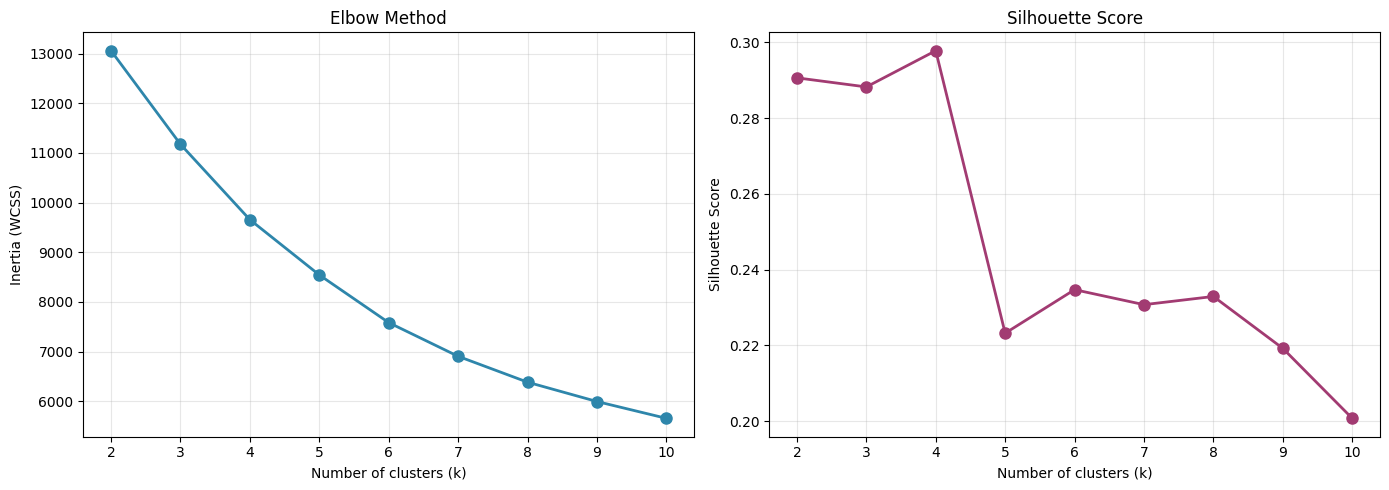

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load
df = pd.read_csv('final_project_dataset.csv', dtype={'FIPS': str})
features = ['Unemployment Rate', 'ACCESS2', 'CHECKUP', 'DENTAL', 'MHLTH', 'PHLTH']
X = df[features].values

# Scale (same scaler we'll save and ship to the Space later)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sweep k
k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Print table
print(f"{'k':>3} | {'Inertia':>10} | {'Silhouette':>10}")
print("-" * 32)
for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"{k:>3} | {i:>10.2f} | {s:>10.4f}")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'o-', color='#2E86AB', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method'); axes[0].grid(alpha=0.3)
axes[1].plot(list(k_range), silhouettes, 'o-', color='#A23B72', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
import joblib

# Re-fit final K-Means at validated k=4
final_k = 4
final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['Cluster_ID'] = final_kmeans.fit_predict(X_scaled)

# Persist artifacts for the deployed app
joblib.dump(final_kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved: kmeans_model.pkl, scaler.pkl\n")

# Profile each cluster: 6 clustering features + count + Labor Force as size context
profile = df.groupby('Cluster_ID').agg(
    n_counties=('FIPS', 'count'),
    avg_labor_force=('Labor Force', 'mean'),
    avg_unemp=('Unemployment Rate', 'mean'),
    avg_uninsured=('ACCESS2', 'mean'),
    avg_checkup=('CHECKUP', 'mean'),
    avg_dental=('DENTAL', 'mean'),
    avg_mental_distress=('MHLTH', 'mean'),
    avg_physical_distress=('PHLTH', 'mean'),
).round(2)
profile['pct_of_total'] = (profile['n_counties'] / len(df) * 100).round(1)

print("=== CLUSTER PROFILES (k=4) ===")
print(profile.to_string())

Saved: kmeans_model.pkl, scaler.pkl

=== CLUSTER PROFILES (k=4) ===
            n_counties  avg_labor_force  avg_unemp  avg_uninsured  avg_checkup  avg_dental  avg_mental_distress  avg_physical_distress  pct_of_total
Cluster_ID                                                                                                                                          
0                  468         60753.99       4.38          16.01        71.91       52.80                18.52                  15.56          14.9
1                 1472         78371.06       3.42           6.40        76.42       65.16                15.52                  12.77          46.8
2                 1121         22003.53       4.55           8.61        78.47       55.11                19.03                  16.86          35.7
3                   82         15505.33       3.70          10.94        79.77        8.16                17.62                  15.95           2.6


In [ ]:
from scipy import stats

# === Sanity check: which states own the 82 Frontier Care Gaps counties? ===
print("=== n=82 cluster — state breakdown ===")
print(df[df['Cluster_ID'] == 3]['County Name'].str[-2:].value_counts().head(10))
print(f"Mean labor force in this cluster: {df[df['Cluster_ID']==3]['Labor Force'].mean():.0f}\n")

# === Step 1.4: Lock in cluster names and save analysis-ready file ===
cluster_names = {
    0: 'Healthcare Deserts',
    1: 'Healthy Workforce Hubs',
    2: 'Distressed Heartland',
    3: 'Frontier Care Gaps'
}
df['Cluster_Name'] = df['Cluster_ID'].map(cluster_names)
df.to_csv('clusters_named.csv', index=False)
print(f"Saved clusters_named.csv ({df.shape[0]} counties, {df.shape[1]} columns)\n")

# === RQ1: Healthcare access vs unemployment ===
print("=== RQ1: Healthcare access vs unemployment ===\n")

for var, label in [('ACCESS2', 'Uninsured rate'),
                   ('CHECKUP', 'Routine checkup rate'),
                   ('DENTAL',  'Dental visit rate')]:
    r, p = stats.pearsonr(df[var], df['Unemployment Rate'])
    print(f"  Unemployment vs {label:<22} r = {r:+.3f}   p = {p:.2e}")

# Quartile gap test
q1, q4 = df['ACCESS2'].quantile([0.25, 0.75])
low_uninsured  = df[df['ACCESS2'] <= q1]['Unemployment Rate']
high_uninsured = df[df['ACCESS2'] >= q4]['Unemployment Rate']
t, p = stats.ttest_ind(high_uninsured, low_uninsured, equal_var=False)

print(f"\n  Top 25% uninsured counties:    mean unemp = {high_uninsured.mean():.2f}%")
print(f"  Bottom 25% uninsured counties: mean unemp = {low_uninsured.mean():.2f}%")
print(f"  Difference: {high_uninsured.mean() - low_uninsured.mean():+.2f} pp")
print(f"  Welch's t-test: t = {t:.2f}, p = {p:.2e}")

# Cluster-level unemployment summary
print("\n=== Unemployment by cluster ===")
print(df.groupby('Cluster_Name')['Unemployment Rate'].agg(['mean', 'count']).round(2))

=== n=82 cluster — state breakdown ===
County Name
MS    82
Name: count, dtype: int64
Mean labor force in this cluster: 15505

Saved clusters_named.csv (3143 counties, 11 columns)

=== RQ1: Healthcare access vs unemployment ===

  Unemployment vs Uninsured rate         r = +0.129   p = 3.29e-13
  Unemployment vs Routine checkup rate   r = +0.014   p = 4.32e-01
  Unemployment vs Dental visit rate      r = -0.218   p = 5.33e-35

  Top 25% uninsured counties:    mean unemp = 4.23%
  Bottom 25% uninsured counties: mean unemp = 3.75%
  Difference: +0.48 pp
  Welch's t-test: t = 6.81, p = 1.38e-11

=== Unemployment by cluster ===
                        mean  count
Cluster_Name                       
Distressed Heartland    4.55   1121
Frontier Care Gaps      3.70     82
Healthcare Deserts      4.38    468
Healthy Workforce Hubs  3.42   1472


In [ ]:
cluster_names = {
    0: 'Healthcare Deserts',
    1: 'Healthy Workforce Hubs',
    2: 'Distressed Heartland',
    3: 'Mississippi Healthcare Gap'
}
df['Cluster_Name'] = df['Cluster_ID'].map(cluster_names)
df.to_csv('clusters_named.csv', index=False)

In [ ]:
import plotly.express as px
import pandas as pd
import joblib

# Reload everything since runtime restarted
df = pd.read_csv('clusters_named.csv', dtype={'FIPS': str})
scaler = joblib.load('scaler.pkl')

color_map = {
    'Healthy Workforce Hubs':      '#2E86AB',
    'Distressed Heartland':        '#F18F01',
    'Healthcare Deserts':          '#A23B72',
    'Mississippi Healthcare Gap':  '#C73E1D'
}

fig = px.choropleth(
    df,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='FIPS',
    color='Cluster_Name',
    color_discrete_map=color_map,
    scope='usa',
    hover_name='County Name',
    hover_data={'FIPS': False, 'Unemployment Rate': ':.1f',
                'ACCESS2': ':.1f', 'Cluster_Name': True},
    title='Healthcare-Labor County Archetypes Across 3,143 U.S. Counties'
)
fig.update_layout(title_x=0.5, title_font_size=18, legend_title_text='Cluster',
                  margin={"r":0,"t":50,"l":0,"b":0}, height=600)

fig.write_html('cluster_map.html')
print("Saved: cluster_map.html")

try:
    fig.write_image('cluster_map.png', width=1400, height=800, scale=2)
    print("Saved: cluster_map.png")
except Exception as e:
    print(f"PNG export skipped ({type(e).__name__}). Use the HTML — screenshot it for the deck.")

fig.show()

Saved: cluster_map.html
Saved: cluster_map.png


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



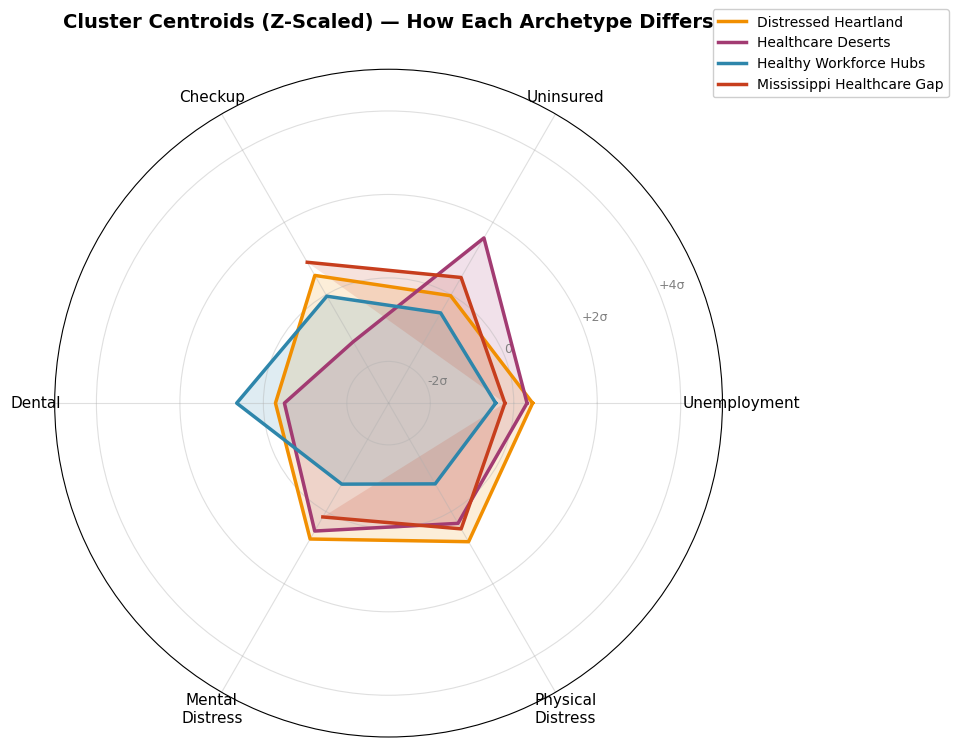

Saved: cluster_radar.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features = ['Unemployment Rate', 'ACCESS2', 'CHECKUP', 'DENTAL', 'MHLTH', 'PHLTH']
feature_labels = ['Unemployment', 'Uninsured', 'Checkup', 'Dental', 'Mental\nDistress', 'Physical\nDistress']

centroids_raw = df.groupby('Cluster_Name')[features].mean()
centroids_z = pd.DataFrame(scaler.transform(centroids_raw),
                           index=centroids_raw.index, columns=features)

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for cluster in centroids_z.index:
    values = centroids_z.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color_map[cluster], linewidth=2.5, label=cluster)
    ax.fill(angles, values, color=color_map[cluster], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_labels, fontsize=11)
ax.set_ylim(-3, 5)
ax.set_yticks([-2, 0, 2, 4])
ax.set_yticklabels(['-2σ', '0', '+2σ', '+4σ'], fontsize=9, color='gray')
ax.grid(True, alpha=0.4)
ax.set_title('Cluster Centroids (Z-Scaled) — How Each Archetype Differs',
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig('cluster_radar.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: cluster_radar.png")

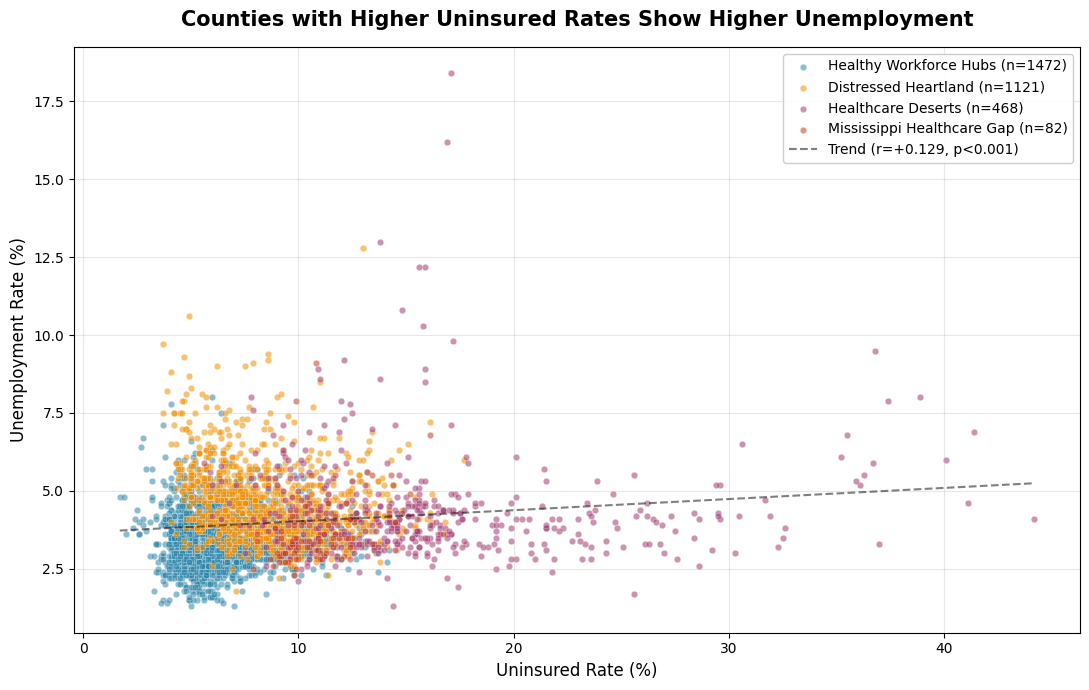

Saved: rq1_scatter.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
for cluster in df['Cluster_Name'].unique():
    sub = df[df['Cluster_Name'] == cluster]
    ax.scatter(sub['ACCESS2'], sub['Unemployment Rate'],
               c=color_map[cluster], label=f'{cluster} (n={len(sub)})',
               alpha=0.55, s=22, edgecolors='white', linewidths=0.3)

z = np.polyfit(df['ACCESS2'], df['Unemployment Rate'], 1)
xx = np.linspace(df['ACCESS2'].min(), df['ACCESS2'].max(), 100)
ax.plot(xx, z[0]*xx + z[1], '--', color='black', alpha=0.5,
        label='Trend (r=+0.129, p<0.001)')

ax.set_xlabel('Uninsured Rate (%)', fontsize=12)
ax.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax.set_title('Counties with Higher Uninsured Rates Show Higher Unemployment',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rq1_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: rq1_scatter.png")

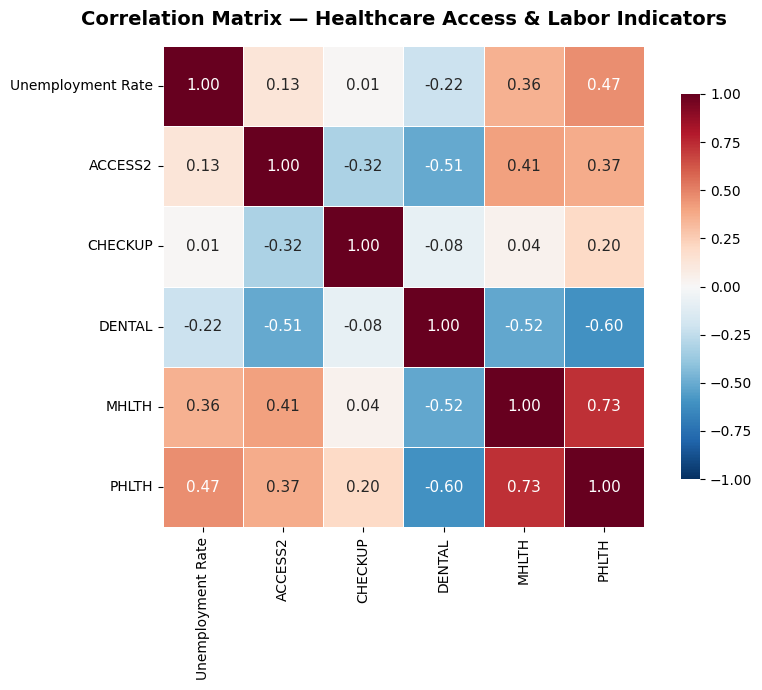

Saved: correlation_heatmap.png


In [ ]:
import seaborn as sns

corr_features = ['Unemployment Rate', 'ACCESS2', 'CHECKUP', 'DENTAL', 'MHLTH', 'PHLTH']
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 11}, ax=ax)
ax.set_title('Correlation Matrix — Healthcare Access & Labor Indicators',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")

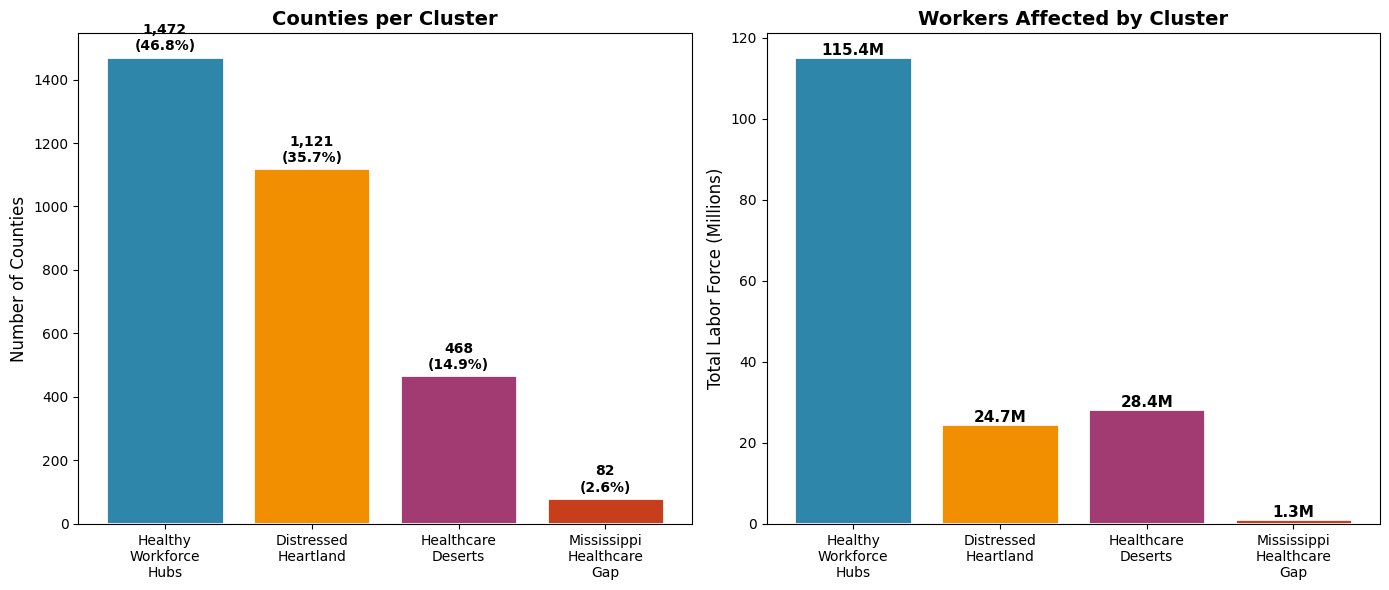

Saved: cluster_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = ['Healthy Workforce Hubs', 'Distressed Heartland', 'Healthcare Deserts', 'Mississippi Healthcare Gap']
colors_ordered = [color_map[c] for c in order]

counts = df['Cluster_Name'].value_counts().reindex(order)
bars = axes[0].bar(range(len(counts)), counts.values, color=colors_ordered, edgecolor='white', linewidth=2)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels([c.replace(' ', '\n') for c in counts.index], fontsize=10)
axes[0].set_ylabel('Number of Counties', fontsize=12)
axes[0].set_title('Counties per Cluster', fontsize=14, fontweight='bold')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

labor_totals = df.groupby('Cluster_Name')['Labor Force'].sum().reindex(order) / 1e6
bars = axes[1].bar(range(len(labor_totals)), labor_totals.values,
                   color=colors_ordered, edgecolor='white', linewidth=2)
axes[1].set_xticks(range(len(labor_totals)))
axes[1].set_xticklabels([c.replace(' ', '\n') for c in labor_totals.index], fontsize=10)
axes[1].set_ylabel('Total Labor Force (Millions)', fontsize=12)
axes[1].set_title('Workers Affected by Cluster', fontsize=14, fontweight='bold')
for bar, val in zip(bars, labor_totals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}M', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: cluster_summary.png")